# EVALUATION NOTEBOOK- PPO Agent

### MiniGrid MultiRoom Environment - Evaluation Notebook

In [ ]:
# MiniGrid MultiRoom Environment - Evaluation Notebook

# First, let's import the necessary libraries
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
import minigrid
from minigrid.wrappers import RGBImgPartialObsWrapper, ImgObsWrapper
import matplotlib.pyplot as plt
import imageio
import base64
from IPython.display import HTML
import os
from gymnasium.wrappers import RecordVideo

print("Libraries loaded successfully!")

Libraries loaded successfully!


## Replace these with correct paths

In [ ]:
NUM_EPISODES = 10 # Detarmine how many episodes you like

In [ ]:
# # Now let's load and evaluate the trained models

# Define paths to model weights
model_paths = {
    "small": "/path/to/ppo_agent_small_room.pt",  # Replace with actual path
    "medium": "/path/to/ppo_agent_medium_room.pt",  # Replace with actual path
    "large": "/path/to/ppo_agent_large_room.pt"  # Replace with actual path
}

# model_paths = {
# "small": "Agent-Experiment/ppo_agent_smart_rewards_2025-03-15-20-36-39.pt",  # Small env
# "medium": "Agent-Experiment/ppo_agent_medium_rooms_2025-03-15-20-55-32.pt",  # Small env
# "large": "Agent-Experiment/ppo_agent_large_rooms_2025-03-15-21-26-48.pt"     # Large env
# }

env_ids = {
    "small": "MiniGrid-MultiRoom-N2-S4-v0",
    "medium": "MiniGrid-MultiRoom-N4-S5-v0",
    "large": "MiniGrid-MultiRoom-N6-v0"
}

In [ ]:
# Define the action space wrapper
class LimitedActionWrapper(gym.ActionWrapper):
    """
    Wrapper to limit the action space to only necessary actions.
    For MiniGrid navigation, we need:
    - 0: Turn left
    - 1: Turn right
    - 2: Move forward
    - 5: Toggle (for opening doors)
    """
    def __init__(self, env):
        super().__init__(env)
        # Map original actions to new action space
        self.action_map = {
            0: 0,  # Left
            1: 1,  # Right
            2: 2,  # Forward
            3: 5   # Toggle (was originally at index 5)
        }
        # Define new action space
        self.action_space = gym.spaces.Discrete(4)  # 4 actions: left, right, forward, toggle

    def action(self, act):
        # Convert from new action space to original action space
        return self.action_map[act]

# Define the smart reward wrapper
class SmartDoorCrossingWrapper(gym.Wrapper):
    """
    Improved reward wrapper that:
    1. Tracks visited rooms to only give a door bonus when entering a new room
    2. Applies a small step penalty to encourage efficiency
    3. Preserves the goal reward for reaching the target
    """
    def __init__(self, env, step_penalty=-0.001, door_bonus=5.0, goal_bonus=15.0):
        super().__init__(env)
        self.step_penalty = step_penalty
        self.door_bonus = door_bonus
        self.goal_bonus = goal_bonus
        self.prev_cell = None
        self.visited_rooms = set()  # Track rooms the agent has visited
        self.current_room_id = None

    def _get_room_id(self):
        """
        Identify the current room by checking agent's coordinates.
        """
        if not hasattr(self.unwrapped, 'agent_pos'):
            return None

        # Get current agent position
        x, y = self.unwrapped.agent_pos

        # Rooms in MultiRoom are typically rectangular regions
        room_id = (x // 5, y // 5)  # Divide by grid size to get room identifier
        return room_id

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        # Clear room tracking
        self.visited_rooms = set()
        self.prev_cell = None

        # Add initial room to visited set
        self.current_room_id = self._get_room_id()
        if self.current_room_id:
            self.visited_rooms.add(self.current_room_id)

        # Identify the cell the agent is currently standing on
        if hasattr(self.unwrapped, 'agent_pos'):
            x, y = self.unwrapped.agent_pos
            self.prev_cell = self.unwrapped.grid.get(x, y)

        return obs, info

    def step(self, action):
        # Take the action in the environment
        obs, reward, done, truncated, info = self.env.step(action)

        # Start with the original reward
        shaped_reward = reward

        # Add step penalty for efficiency (if not done)
        if not done:
            shaped_reward += self.step_penalty

        # If the agent reached the goal (original reward is positive), add bonus
        if reward > 0:
            shaped_reward += self.goal_bonus

        # Check if the agent crossed a door into a new room
        if hasattr(self.unwrapped, 'agent_pos'):
            x, y = self.unwrapped.agent_pos
            cell = self.unwrapped.grid.get(x, y)

            # Check if the agent is on a door
            if cell is not None and hasattr(cell, 'type') and cell.type == 'door':
                # Check if the agent wasn't previously on a door
                if self.prev_cell is None or self.prev_cell.type != 'door':
                    # Get the new room ID after potentially crossing a door
                    new_room_id = self._get_room_id()

                    # If the room ID changed and it's a new room, add the door bonus
                    if new_room_id and new_room_id != self.current_room_id and new_room_id not in self.visited_rooms:
                        shaped_reward += self.door_bonus
                        self.visited_rooms.add(new_room_id)
                        self.current_room_id = new_room_id

            # Update the previous cell
            self.prev_cell = cell

        return obs, shaped_reward, done, truncated, info

# Define helper function for creating environments
def make_env(env_id="MiniGrid-MultiRoom-N6-v0", seed=None, render_mode="rgb_array",
            use_smart_rewards=True, step_penalty=-0.001, door_bonus=5.0, goal_bonus=15.0):
    """Create and wrap a MiniGrid environment"""
    env = gym.make(env_id, render_mode=render_mode)

    # Apply reward wrapper
    if use_smart_rewards:
        env = SmartDoorCrossingWrapper(env, step_penalty=step_penalty,
                                     door_bonus=door_bonus, goal_bonus=goal_bonus)

    # Apply observation wrappers
    env = RGBImgPartialObsWrapper(env)  # Get pixel observations
    env = ImgObsWrapper(env)  # Convert dict to image array

    # Apply action space wrapper
    env = LimitedActionWrapper(env)

    # Set seed if provided
    if seed is not None:
        env.reset(seed=seed)

    return env

# Define the Actor-Critic network
class ActorCritic(nn.Module):
    def __init__(self, input_shape, num_actions):
        super(ActorCritic, self).__init__()

        # CNN Layers
        self.conv = nn.Sequential(
            nn.Conv2d(input_shape[0], 32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Flatten()
        )

        # Calculate the output size after conv layers
        with torch.no_grad():
            dummy_input = torch.zeros(1, *input_shape)
            conv_out = self.conv(dummy_input)
            conv_out_size = conv_out.shape[1]

        # Shared feature layers
        self.fc = nn.Sequential(
            nn.Linear(conv_out_size, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU()
        )

        # Actor head (policy)
        self.actor = nn.Linear(128, num_actions)

        # Critic head (value function)
        self.critic = nn.Linear(128, 1)

    def forward(self, x):
        # Normalize pixel values
        x = x / 255.0

        # Process through CNN
        conv_features = self.conv(x)

        # Process through shared layers
        features = self.fc(conv_features)

        # Get action logits and state value
        action_logits = self.actor(features)
        state_value = self.critic(features)

        return action_logits, state_value

# Define the PPO Agent
class PPOAgent:
    def __init__(self, input_shape, num_actions):
        self.model = ActorCritic(input_shape, num_actions)
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.model.to(self.device)

    def select_action(self, state):
        """Select action using the policy network"""
        with torch.no_grad():
            # Convert state to PyTorch tensor
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(self.device)

            # Get action logits and value
            logits, value = self.model(state_tensor)

            # Convert logits to probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample action from the distribution
            dist = torch.distributions.Categorical(probs)
            action = dist.sample()

            # Get log probability of the action
            log_prob = dist.log_prob(action)

        return action.item(), log_prob.item(), value.item()

    def load(self, path):
        """Load the model weights"""
        self.model.load_state_dict(torch.load(path, map_location=self.device))
        print(f"Model loaded from {path}")

# Function to embed videos
def embed_mp4(filename):
    """Embeds an mp4 file in the notebook."""
    video = open(filename,'rb').read()
    b64 = base64.b64encode(video)
    tag = f'''
    <video width="640" height="480" controls>
        <source src="data:video/mp4;base64,{b64.decode()}" type="video/mp4">
    Your browser does not support the video tag.
    </video>'''
    return HTML(tag)

# Function to evaluate agents and generate videos
def evaluate_agent(agent, env_id, num_episodes=5, save_video=True,
                  video_path="agent_evaluation.mp4"):
    """
    Evaluate an agent on the specified environment and optionally record a video
    """
    # Create environment
    env = make_env(env_id, render_mode="rgb_array")

    # Add video recording wrapper if requested
    if save_video:
        video_dir = os.path.dirname(video_path)
        if not os.path.exists(video_dir) and video_dir:
            os.makedirs(video_dir)

        env = RecordVideo(
            env,
            video_folder=os.path.dirname(video_path),
            name_prefix=os.path.basename(video_path).split('.')[0],
            episode_trigger=lambda episode_id: episode_id < num_episodes
        )

    # Initialize metrics
    total_rewards = []
    episode_lengths = []
    success_count = 0

    # Run evaluation episodes
    for episode in range(num_episodes):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        steps = 0

        # Run episode
        while not (done or truncated):
            # Convert observation for agent
            if isinstance(obs, np.ndarray):
                state = np.transpose(obs, (2, 0, 1))  # HWC to CHW format
            else:
                state = np.transpose(obs["image"], (2, 0, 1))

            # Get action from agent
            action, _, _ = agent.select_action(state)

            # Take step in environment
            obs, reward, done, truncated, _ = env.step(action)
            total_reward += reward
            steps += 1

        # Record episode results
        total_rewards.append(total_reward)
        episode_lengths.append(steps)
        if total_reward > 0:
            success_count += 1

        print(f"Episode {episode+1}: Reward={total_reward:.2f}, Steps={steps}, Success={total_reward > 0}")

    # Calculate and print metrics
    success_rate = (success_count / num_episodes) * 100
    avg_reward = np.mean(total_rewards)
    avg_length = np.mean(episode_lengths)

    print(f"\nEvaluation Results:")
    print(f"Success Rate: {success_rate:.1f}%")
    print(f"Average Reward: {avg_reward:.2f}")
    print(f"Average Episode Length: {avg_length:.1f} steps")

    # Close environment
    env.close()

    return total_rewards, episode_lengths, success_rate, video_path if save_video else None

In [ ]:
# Function to load and evaluate a single model
def load_and_evaluate_model(model_name, num_episodes=5):
    # Get model path and environment ID
    model_path = model_paths[model_name]
    env_id = env_ids[model_name]

    print(f"Evaluating {model_name} environment agent: {env_id}")

    # Create temporary environment to get observation shape
    temp_env = make_env(env_id)
    obs, _ = temp_env.reset()
    obs_shape = obs.shape  # (H, W, C)
    input_shape = (obs_shape[2], obs_shape[0], obs_shape[1])  # CHW format
    num_actions = temp_env.action_space.n
    temp_env.close()

    print(f"Observation shape: {obs_shape}, Input shape: {input_shape}, Action space: {num_actions}")

    # Create agent and load weights
    agent = PPOAgent(input_shape, num_actions)
    agent.load(model_path)

    # Evaluate agent and save video
    video_path = f"{model_name}_environment_evaluation.mp4"
    rewards, lengths, success_rate, video_path = evaluate_agent(
        agent,
        env_id,
        num_episodes=num_episodes,
        video_path=video_path
    )

    # Display video if available
    if video_path and os.path.exists(video_path):
        display(embed_mp4(video_path))

    return rewards, lengths, success_rate

##  Main evaluation section -
### Uncomment and run each cell to evaluate each model

In [ ]:

#  Main evaluation section - uncomment and run each cell to evaluate each model

#1. Evaluate small environment agent
small_rewards, small_lengths, small_success = load_and_evaluate_model("small", num_episodes=NUM_EPISODES)

Evaluating small environment agent: MiniGrid-MultiRoom-N2-S4-v0
Observation shape: (56, 56, 3), Input shape: (3, 56, 56), Action space: 4


/root/.ipykernel/42918/command-1724836983401721-2861720112:221: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Model loaded from /Workspace/Users//Agent-Experiment/ppo_agent_smart_rewards_2025-03-15-20-36-39.pt


/databricks/python/lib/python3.12/site-packages/gymnasium/wrappers/record_video.py:87: UserWarning:

WARN: Overwriting existing videos at /Workspace/Users//Agent-Experiment folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)



MoviePy - Building video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-0.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-0.mp4



...

MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-5.mp4
Episode 6: Reward=15.72, Steps=12, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-6.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-6.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-6.mp4
Episode 7: Reward=20.25, Steps=32, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-7.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-7.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-7.mp4
Episode 8: Reward=20.58, Steps=18, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-8.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-8.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-8.mp4
Episode 9: Reward=15.81, Steps=8, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-9.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-9.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/small_environment_evaluation-episode-9.mp4
Episode 10: Reward=-0.04, Steps=40, Success=False

Evaluation Results:
Success Rate: 90.0%
Average Reward: 16.10
Average Episode Length: 16.7 steps


In [ ]:

#2. Evaluate medium environment agent
medium_rewards, medium_lengths, medium_success = load_and_evaluate_model("medium", num_episodes=NUM_EPISODES)


Evaluating medium environment agent: MiniGrid-MultiRoom-N4-S5-v0
Observation shape: (56, 56, 3), Input shape: (3, 56, 56), Action space: 4


/root/.ipykernel/42918/command-1724836983401721-2861720112:221: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Model loaded from /Workspace/Users//Agent-Experiment/ppo_agent_medium_rooms_2025-03-15-20-55-32.pt
MoviePy - Building video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-0.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-0.mp4
Episode 1: Reward=35.21, Steps=93, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-1.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-1.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-1.mp4
Episode 2: Reward=25.20, Steps=94, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-2.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-2.mp4



...

MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-5.mp4
Episode 6: Reward=30.47, Steps=62, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-6.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-6.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-6.mp4
Episode 7: Reward=9.88, Steps=120, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-7.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-7.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-7.mp4
Episode 8: Reward=4.88, Steps=120, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-8.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-8.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-8.mp4
Episode 9: Reward=30.63, Steps=44, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-9.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-9.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/medium_environment_evaluation-episode-9.mp4
Episode 10: Reward=30.26, Steps=87, Success=True

Evaluation Results:
Success Rate: 100.0%
Average Reward: 25.77
Average Episode Length: 84.0 steps


In [ ]:

#3. Evaluate large environment agent
large_rewards, large_lengths, large_success = load_and_evaluate_model("large", num_episodes=NUM_EPISODES)

Evaluating large environment agent: MiniGrid-MultiRoom-N6-v0
Observation shape: (56, 56, 3), Input shape: (3, 56, 56), Action space: 4


/root/.ipykernel/42918/command-1724836983401721-2861720112:221: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



Model loaded from /Workspace/Users//Agent-Experiment/ppo_agent_large_rooms_2025-03-15-21-26-48.pt
MoviePy - Building video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-0.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-0.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-0.mp4
Episode 1: Reward=40.27, Steps=86, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-1.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-1.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-1.mp4
Episode 2: Reward=30.45, Steps=65, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-2.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-2.mp4



...

MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-5.mp4
Episode 6: Reward=9.88, Steps=120, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-6.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-6.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-6.mp4
Episode 7: Reward=40.33, Steps=79, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-7.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-7.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-7.mp4
Episode 8: Reward=35.29, Steps=84, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-8.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-8.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-8.mp4
Episode 9: Reward=34.98, Steps=120, Success=True
MoviePy - Building video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-9.mp4.
MoviePy - Writing video /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-9.mp4



MoviePy - Done !
MoviePy - video ready /Workspace/Users//Agent-Experiment/large_environment_evaluation-episode-9.mp4
Episode 10: Reward=40.30, Steps=83, Success=True

Evaluation Results:
Success Rate: 100.0%
Average Reward: 30.72
Average Episode Length: 90.0 steps


In [ ]:
# Visualization and comparison
def plot_evaluation_results(small_results, medium_results, large_results):
    """Plot comparison of agent performance across environments"""
    # Extract metrics
    envs = ["Small (N2-S4)", "Medium (N4-S5)", "Large (N6-v0)"]
    success_rates = [small_results[2], medium_results[2], large_results[2]]
    avg_lengths = [np.mean(small_results[1]), np.mean(medium_results[1]), np.mean(large_results[1])]
    avg_rewards = [np.mean(small_results[0]), np.mean(medium_results[0]), np.mean(large_results[0])]

    # Create figure with subplots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Plot success rates
    axes[0].bar(envs, success_rates, color=['skyblue', 'lightgreen', 'salmon'])
    axes[0].set_title("Success Rate Comparison")
    axes[0].set_ylabel("Success Rate (%)")
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot average episode lengths
    axes[1].bar(envs, avg_lengths, color=['skyblue', 'lightgreen', 'salmon'])
    axes[1].set_title("Average Episode Length")
    axes[1].set_ylabel("Steps")
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)

    # Plot average rewards
    axes[2].bar(envs, avg_rewards, color=['skyblue', 'lightgreen', 'salmon'])
    axes[2].set_title("Average Reward")
    axes[2].set_ylabel("Reward")
    axes[2].grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig("agent_performance_comparison.png")
    plt.show()

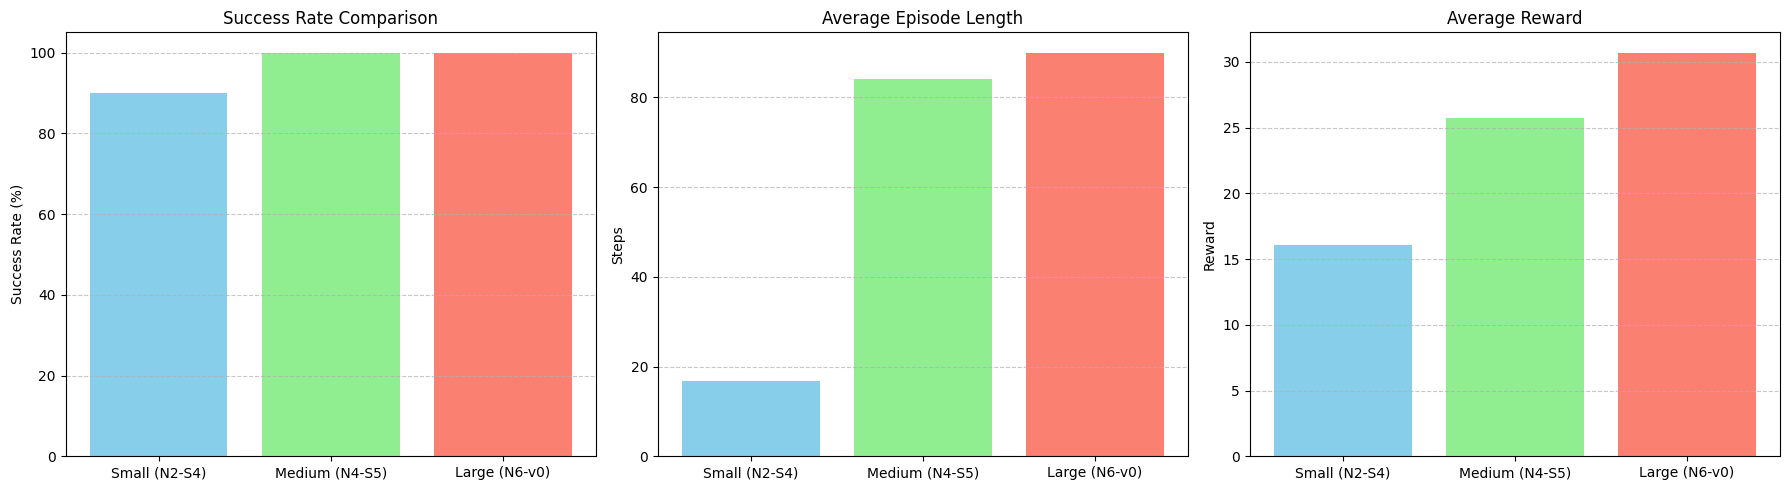

Evaluation notebook complete!


In [ ]:
#Uncomment the line below after evaluating all agents
plot_evaluation_results((small_rewards, small_lengths, small_success),
                        (medium_rewards, medium_lengths, medium_success),
                        (large_rewards, large_lengths, large_success))

print("Evaluation notebook complete!")